In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.getcwd()

'C:\\Users\\user'

In [4]:
import os

os.listdir("Downloads")

['08_Handwritten_Digit_Recognition_SVM.ipynb',
 'AM_end_24.pdf',
 'AM_end_may25.pdf',
 'Anaconda3-2025.12-2-Windows-x86_64.exe',
 'Arogya',
 'b31314b67880afecd6b8d584d04112f1c346c033IDS Unit 1 Notes.docx',
 'Boston_Housing_Regression.ipynb',
 'Breast_Cancer_Classification_KNN.ipynb',
 'ChromeSetup.exe',
 'Code',
 'Customer_Churn_Prediction_using_Machine_Learning.ipynb',
 'desktop.ini',
 'End_reappear_21.pdf',
 'exam_attendance_sheet_1_1.pdf',
 'first',
 'Git-2.53.0.2-64-bit.exe',
 'Hachthon',
 'heart_disease_uci.csv',
 'heart_pred_disision_tree.ipynb',
 'heart_pred_random_forest.ipynb',
 'HR_Analytics.csv',
 'HR_capstone_dataset.csv',
 'INDIAVIX.csv',
 'Iris_Flower_Classification.ipynb',
 'MediEase.fig',
 'new',
 'NIFTY 50.csv',
 'node-v24.14.1-x64.msi',
 'python-3.14.2-amd64.exe',
 'R-4.5.1-win.exe',
 'RStudio-2025.09.1-401.exe',
 'sample_-_superstore.xls',
 'TableauPublicDesktop-64bit-2026-1-0.exe',
 'Telco-Customer-Churn.csv',
 'Telco_Cusomer_Churn.csv',
 'test.json',
 'test.json.zi

In [5]:
df = pd.read_csv("Downloads/heart_disease_uci.csv")

In [6]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [7]:
df.shape

(920, 16)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [9]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [10]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [11]:
df = df.drop("id", axis=1)

In [12]:
df["num"] = (df["num"] > 0).astype(int)

In [13]:
num_cols = ["trestbps", "chol", "thalch", "oldpeak"]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_15804\1650642171.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [14]:
cat_cols = ["fbs", "restecg", "exang", "slope"]

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_15804\964860341.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_15804\964860341.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].fillna(df[col].mode()[0], inplace=

In [15]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalch        0
exang         0
oldpeak       0
slope         0
ca          611
thal        486
num           0
dtype: int64

In [16]:
df = df.drop("ca", axis=1)

In [17]:
print(df.columns)

Index(['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')


In [18]:
df = pd.get_dummies(
    df,
    columns=["sex","dataset","cp","fbs","restecg","exang","slope"],
    drop_first=True
)

In [19]:
df.shape

(920, 20)

In [20]:
df.head()

,age,trestbps,chol,thalch,oldpeak,thal,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,fixed defect,0,True,False,False,False,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,normal,1,True,False,False,False,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,reversable defect,1,True,False,False,False,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,normal,0,True,False,False,False,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,normal,0,False,False,False,False,True,False,False,False,False,False,False,False,True


In [21]:
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

In [22]:
X = df.drop("num", axis=1)
y = df["num"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(736, 19)
(184, 19)
num
1    407
0    329
Name: count, dtype: int64
num
1    102
0     82
Name: count, dtype: int64


In [25]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

ValueError: could not convert string to float: 'reversable defect'

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
print("Actual    :", y_test.values[:10])
print("Predicted :", y_pred[:10])

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
for depth in range(1, 21):
    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(depth, "->", acc)

ValueError: could not convert string to float: 'reversable defect'

# Random Forest Classifier

In [28]:
print(df.select_dtypes(include="object").columns)

Index(['thal'], dtype='object')


In [29]:
df = pd.get_dummies(df, drop_first=True)

In [30]:
X = df.drop("num", axis=1)
y = df["num"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8315217391304348
[[67 15]
 [16 86]]
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        82
           1       0.85      0.84      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [33]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_rf
})

comparison_rf.head(10)

,Actual,Predicted
0,1,0
1,1,1
2,1,1
3,1,1
4,0,1
5,0,1
6,0,0
7,1,1
8,0,0
9,1,1


In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
2,chol,0.132694
3,thalch,0.121635
0,age,0.116975
4,oldpeak,0.098805
15,exang_True,0.094892
1,trestbps,0.076874
9,cp_atypical angina,0.061522
5,sex_Male,0.040238
10,cp_non-anginal,0.032903
18,thal_normal,0.032107


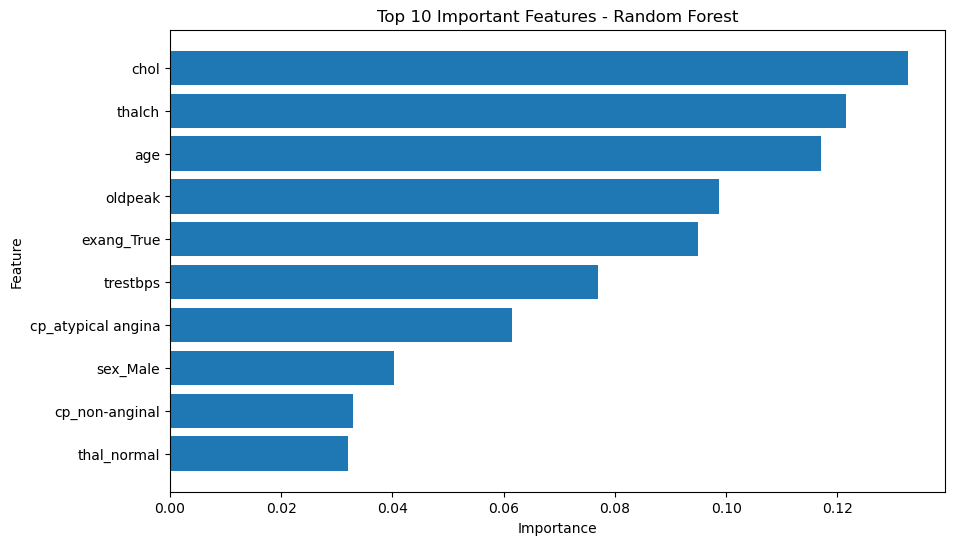

In [35]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [36]:
rf_oob = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)
rf_oob.fit(X_train, y_train)
print("OOB Score:", rf_oob.oob_score_)

OOB Score: 0.8084239130434783


In [37]:
for depth in [3, 5, 7, 10, None]:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    print("max_depth:", depth, "Accuracy:", accuracy_score(y_test, y_pred))

max_depth: 3 Accuracy: 0.8369565217391305
max_depth: 5 Accuracy: 0.842391304347826
max_depth: 7 Accuracy: 0.8315217391304348
max_depth: 10 Accuracy: 0.842391304347826
max_depth: None Accuracy: 0.8315217391304348


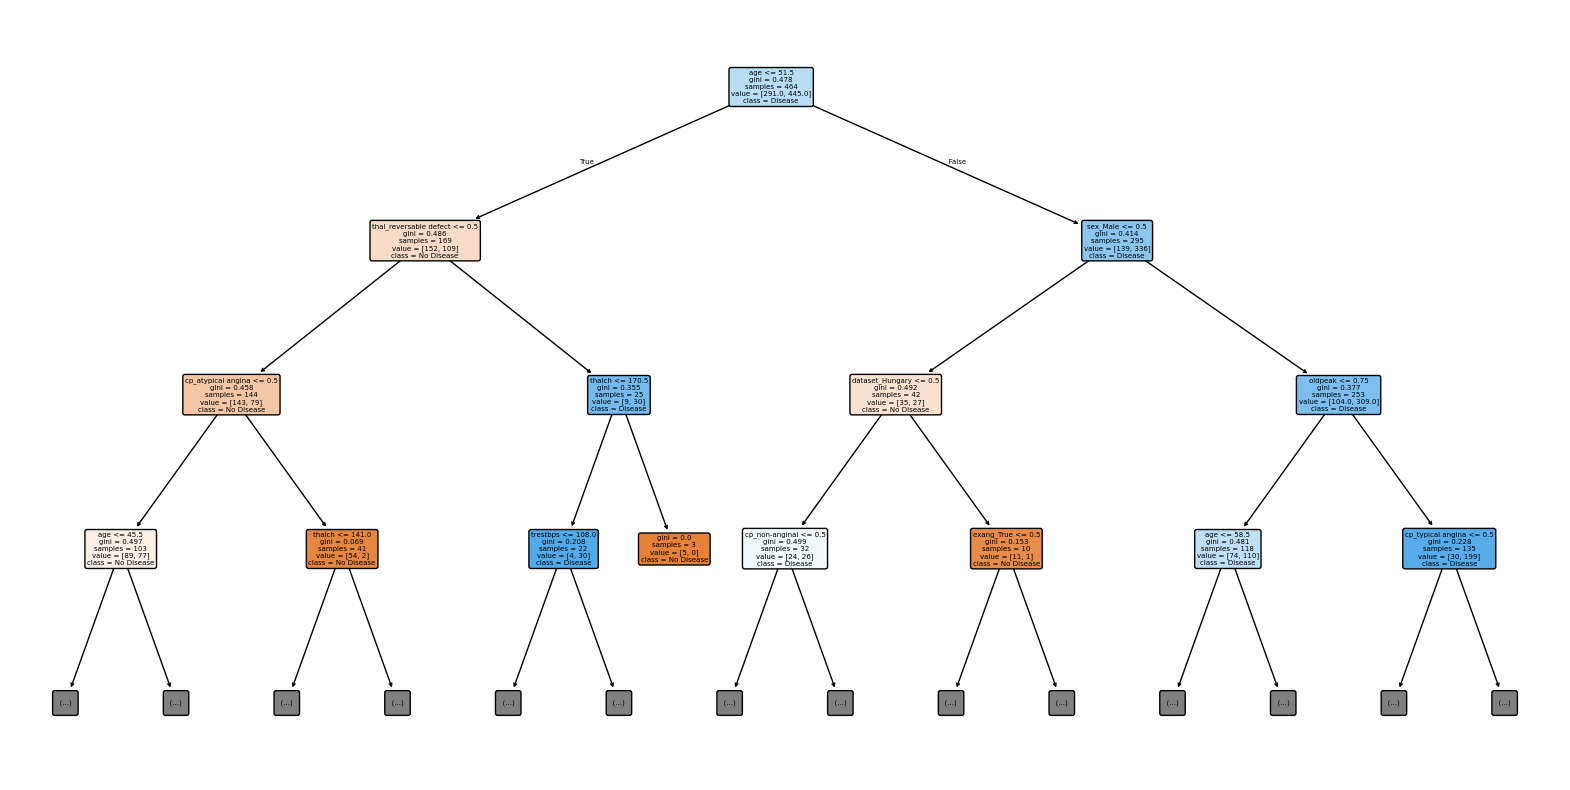

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
single_tree = rf.estimators_[0]
plt.figure(figsize=(20, 10))
plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    max_depth=3
)
plt.show()

Gradient Boosting

In [39]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

train_acc = gb.score(X_train, y_train)
test_acc = gb.score(X_test, y_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9225543478260869
Test Accuracy: 0.842391304347826


In [40]:
from sklearn.ensemble import GradientBoostingClassifier

for lr in [0.01, 0.05, 0.1, 0.2]:
    for n in [50, 100, 200]:
        model = GradientBoostingClassifier(
            n_estimators=n,
            learning_rate=lr,
            random_state=42
        )
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)

        print("Learning Rate:", lr, "| n_estimators:", n)
        print("Train Accuracy:", train_acc)
        print("Test Accuracy:", test_acc)
        print("-" * 50)

Learning Rate: 0.01 | n_estimators: 50
Train Accuracy: 0.8165760869565217
Test Accuracy: 0.8152173913043478
--------------------------------------------------
Learning Rate: 0.01 | n_estimators: 100
Train Accuracy: 0.8410326086956522
Test Accuracy: 0.8369565217391305
--------------------------------------------------
Learning Rate: 0.01 | n_estimators: 200
Train Accuracy: 0.8641304347826086
Test Accuracy: 0.8369565217391305
--------------------------------------------------
Learning Rate: 0.05 | n_estimators: 50
Train Accuracy: 0.8614130434782609
Test Accuracy: 0.8369565217391305
--------------------------------------------------
Learning Rate: 0.05 | n_estimators: 100
Train Accuracy: 0.8804347826086957
Test Accuracy: 0.8315217391304348
--------------------------------------------------
Learning Rate: 0.05 | n_estimators: 200
Train Accuracy: 0.9198369565217391
Test Accuracy: 0.8369565217391305
--------------------------------------------------
Learning Rate: 0.1 | n_estimators: 50
Trai

In [41]:
GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [42]:
train_acc = gb.score(X_train, y_train)
test_acc = gb.score(X_test, y_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9225543478260869
Test Accuracy: 0.842391304347826


In [43]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[66 16]
 [15 87]]
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        82
           1       0.84      0.85      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184

